## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

---

# PRÁCTICA No. 26: CNN(CIFAR-10)

### La CNN se implementará para clasificar imágenes de la base de datos CIFAR-10
### La base de datos CIFAR-10 es un conjunto de datos ampliamente utilizado en visión por computadora y aprendizaje profundo. Contiene imágenes de objetos del mundo real, con las siguientes características: 60,000 imágenes en total (50,000 para entrenamiento y 10,000 para prueba), imágenes a color (RGB) de 32x32 píxeles, y etiquetadas con una de las 10 clases: airplane (avión), automobile (automóvil), bird (pájaro), cat (gato), deer (venado), dog (perro), frog (rana), horse (caballo), ship (barco) y truck (camión)




## Paso 1: Importar las librerías necesarias

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Paso 2: Cargar el dataset CIFAR-10

### CIFAR-10 está incluido directamente en Keras, por lo que es muy fácil de cargar

In [2]:
# Cargar el dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Definir las clases del dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(class_names)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")
print(f"\nNúmero de clases: {num_classes}")
print(f"Clases: {class_names}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Forma de X_train: (50000, 32, 32, 3)
Forma de y_train: (50000, 1)
Forma de X_test: (10000, 32, 32, 3)
Forma de y_test: (10000, 1)

Número de clases: 10
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Paso 3: Explorar los datos

Información del dataset:
Rango de valores de píxeles: 0 a 255
Tipo de datos: uint8
Canales de color (RGB): 3

Distribución de clases en entrenamiento:
airplane: 5000 imágenes
automobile: 5000 imágenes
bird: 5000 imágenes
cat: 5000 imágenes
deer: 5000 imágenes
dog: 5000 imágenes
frog: 5000 imágenes
horse: 5000 imágenes
ship: 5000 imágenes
truck: 5000 imágenes


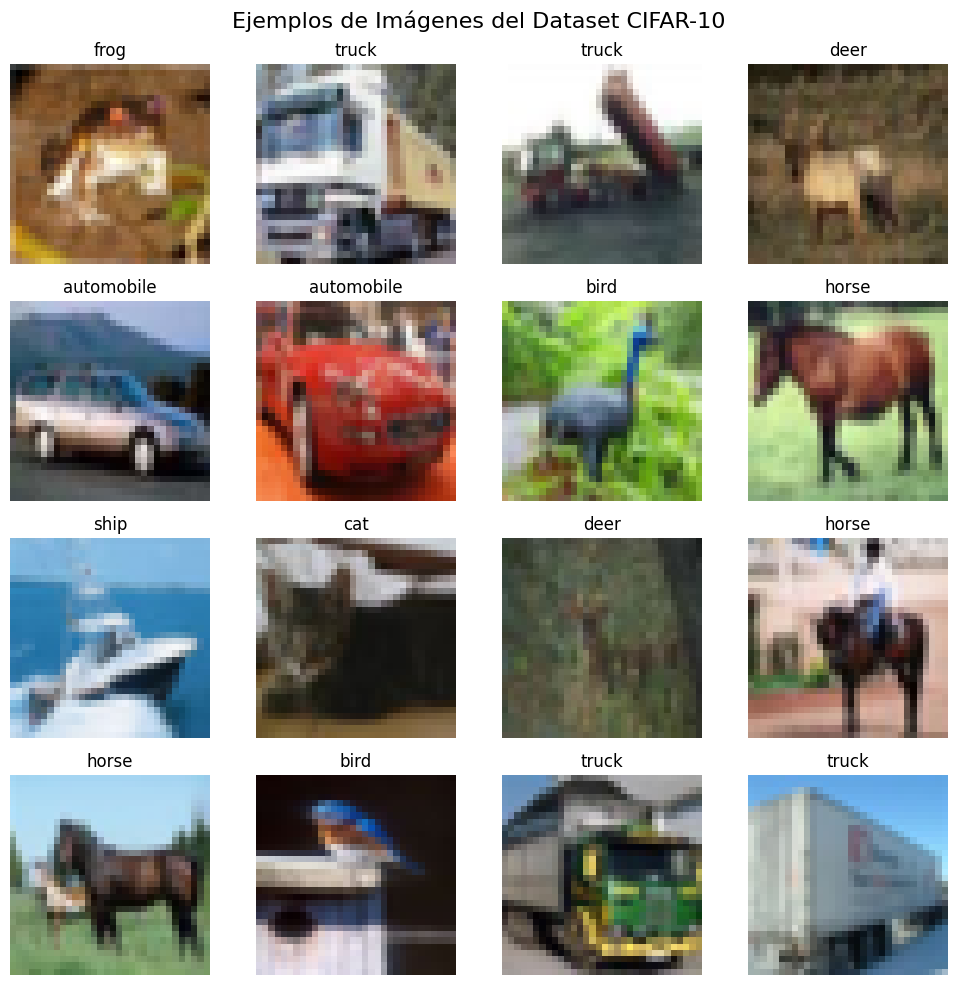

In [3]:
# Visualizar información del dataset
print("Información del dataset:")
print(f"Rango de valores de píxeles: {X_train.min()} a {X_train.max()}")
print(f"Tipo de datos: {X_train.dtype}")
print(f"Canales de color (RGB): {X_train.shape[3]}")

# Distribución de clases en entrenamiento
print("\nDistribución de clases en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for class_idx, count in zip(unique, counts):
    print(f"{class_names[class_idx]}: {count} imágenes")

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Ejemplos de Imágenes del Dataset CIFAR-10', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Mostrar imagen
    ax.imshow(X_train[i])
    # NOTA: Aquí SÍ se mantiene el [0] porque estamos usando y_train original, el cual sigue teniendo la forma (50000, 1)
    ax.set_title(f'{class_names[y_train[i][0]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

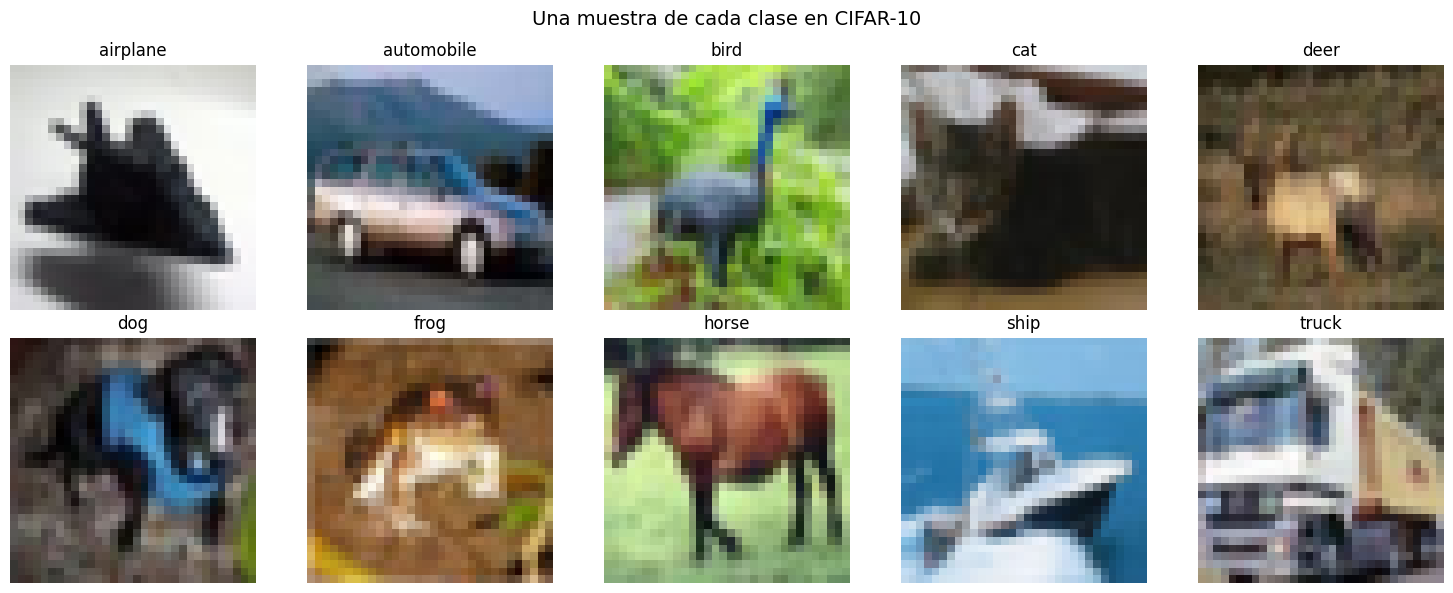

In [4]:
# Mostrar un ejemplo de cada clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Una muestra de cada clase en CIFAR-10', fontsize=14)

for class_idx in range(num_classes):
    # Encontrar el primer ejemplo de esta clase
    idx = np.where(y_train == class_idx)[0][0]
    row = class_idx // 5
    col = class_idx % 5
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(class_names[class_idx])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Paso 4: Preprocesar los datos

In [5]:
# Normalizar los valores de píxeles a rango [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Aplanar las etiquetas (de forma (50000, 1) a (50000,))
y_train = y_train.flatten()
y_test = y_test.flatten()

# Convertir etiquetas a formato categórico (one-hot encoding)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Forma final de X_train: {X_train.shape}")
print(f"Forma final de X_test: {X_test.shape}")
print(f"Forma final de y_train: {y_train.shape}")
print(f"Forma final de y_test: {y_test.shape}")
print(f"Forma final de y_train_cat: {y_train_cat.shape}")
print(f"Forma final de y_test_cat: {y_test_cat.shape}")

# Mostrar un ejemplo de codificación one-hot
print(f"\nEjemplo de etiqueta original: {y_train[0]} ({class_names[y_train[0]]})")
print(f"Etiqueta en formato one-hot: {y_train_cat[0]}")

# Mostrar ejemplo de imagen normalizada
print(f"\nRango de valores después de normalización: {X_train.min():.3f} a {X_train.max():.3f}")

Forma final de X_train: (50000, 32, 32, 3)
Forma final de X_test: (10000, 32, 32, 3)
Forma final de y_train: (50000,)
Forma final de y_test: (10000,)
Forma final de y_train_cat: (50000, 10)
Forma final de y_test_cat: (10000, 10)

Ejemplo de etiqueta original: 6 (frog)
Etiqueta en formato one-hot: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Rango de valores después de normalización: 0.000 a 1.000


## Paso 5: Crear el modelo CNN

### Arquitectura adaptada para imágenes RGB de 32x32 y 10 clases

In [6]:
# Crear el modelo secuencial
model = keras.Sequential()

# Primera capa convolucional - entrada 32x32x3 (RGB)
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu',
                 input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Segunda capa convolucional
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Tercera capa convolucional
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Aplanar la salida para conectar con capas densas
model.add(Flatten())

# Capas totalmente conectadas (densas)
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Capa de salida con 10 neuronas (una para cada clase)
model.add(Dense(num_classes, activation='softmax'))

# Mostrar resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 849,066 (3.24 MB)

 Trainable params: 847,402 (3.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

## Paso 6: Compilar el modelo

In [7]:
# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado exitosamente")

Modelo compilado exitosamente


## Paso 7: Configurar callbacks y data augmentation

In [8]:
# Configurar callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# Configurar data augmentation para mejorar la generalización
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(X_train)

print("Callbacks y data augmentation configurados")

Callbacks y data augmentation configurados


## Paso 8: Entrenar el modelo

In [9]:
# Definir hiperparámetros
batch_size = 64
epochs = 50

# Entrenar el modelo con data augmentation
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=batch_size),
    validation_data=(X_test, y_test_cat),
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

print("Entrenamiento completado")

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.3679 - loss: 1.8432 - val_accuracy: 0.4543 - val_loss: 1.5325 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5209 - loss: 1.3332 - val_accuracy: 0.5618 - val_loss: 1.2656 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.5966 - loss: 1.1395 - val_accuracy: 0.6176 - val_loss: 1.1265 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.6446 - loss: 1.0186 - val_accuracy: 0.6769 - val_loss: 0.9487 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6775 - loss: 0.9295 - val_accuracy: 0.7304 - val_loss: 0.8088 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7039 - loss: 0.8682 - val_accuracy: 0.7257 - val_loss: 0.8160 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7207 - l

## Paso 9: Visualizar el historial de entrenamiento

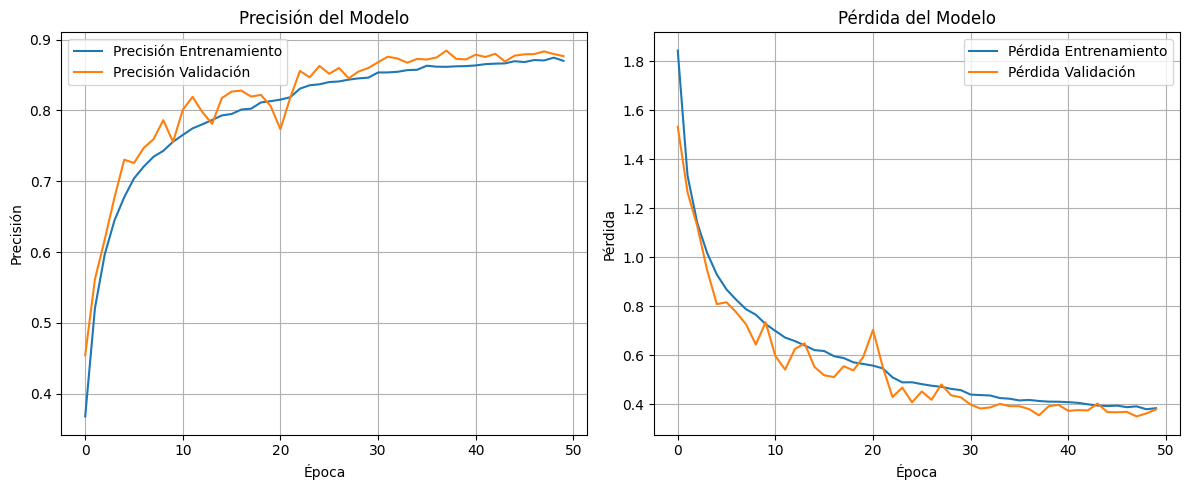

In [10]:
# Graficar la precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Graficar la pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Paso 10: Evaluar el modelo

In [11]:
# Evaluar en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nPérdida en conjunto de prueba: {test_loss:.4f}")
print(f"Precisión en conjunto de prueba: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8833 - loss: 0.3502

Pérdida en conjunto de prueba: 0.3502
Precisión en conjunto de prueba: 0.8833 (88.33%)


## Paso 11: Hacer predicciones y visualizar resultados

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step


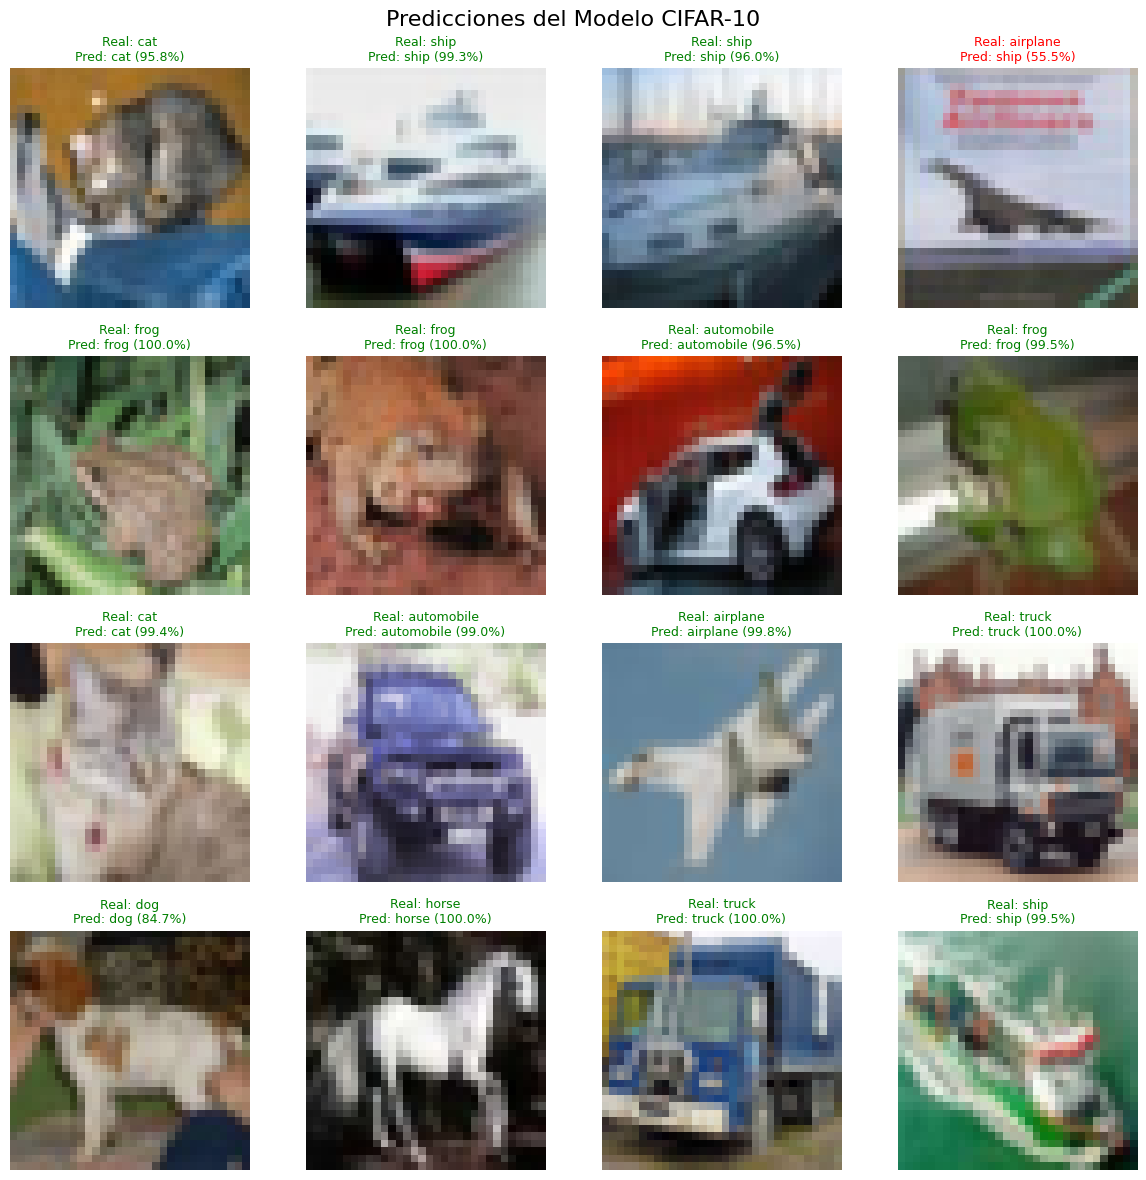

In [12]:
# Hacer predicciones en un subconjunto de prueba
num_predictions = 16
predictions = model.predict(X_test[:num_predictions])

# Obtener las clases predichas
predicted_classes = np.argmax(predictions, axis=1)

# Visualizar las predicciones
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Predicciones del Modelo CIFAR-10', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Mostrar la imagen
    ax.imshow(X_test[i])

    # Obtener la clase real y predicha
    true_class = class_names[y_test[i]]
    pred_class = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]] * 100

    # Color verde si es correcta, rojo si es incorrecta
    color = 'green' if y_test[i] == predicted_classes[i] else 'red'

    ax.set_title(f'Real: {true_class}\nPred: {pred_class} ({confidence:.1f}%)',
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Mostrar algunas predicciones detalladas
print("Ejemplos de predicciones detalladas:")
print("="*70)
for i in range(5):
    print(f"\nImagen {i+1}:")
    print(f"Clase real: {class_names[y_test[i]]}")
    print(f"Clase predicha: {class_names[predicted_classes[i]]}")
    print("Probabilidades por clase:")
    for j, prob in enumerate(predictions[i]):
        print(f"  {class_names[j]}: {prob*100:.2f}%")

Ejemplos de predicciones detalladas:

Imagen 1:
Clase real: cat
Clase predicha: cat
Probabilidades por clase:
  airplane: 0.02%
  automobile: 0.09%
  bird: 0.27%
  cat: 95.80%
  deer: 0.03%
  dog: 3.01%
  frog: 0.69%
  horse: 0.03%
  ship: 0.04%
  truck: 0.02%

Imagen 2:
Clase real: ship
Clase predicha: ship
Probabilidades por clase:
  airplane: 0.02%
  automobile: 0.71%
  bird: 0.00%
  cat: 0.00%
  deer: 0.00%
  dog: 0.00%
  frog: 0.00%
  horse: 0.00%
  ship: 99.27%
  truck: 0.01%

Imagen 3:
Clase real: ship
Clase predicha: ship
Probabilidades por clase:
  airplane: 0.09%
  automobile: 3.69%
  bird: 0.01%
  cat: 0.03%
  deer: 0.02%
  dog: 0.01%
  frog: 0.03%
  horse: 0.02%
  ship: 96.03%
  truck: 0.07%

Imagen 4:
Clase real: airplane
Clase predicha: ship
Probabilidades por clase:
  airplane: 38.69%
  automobile: 0.88%
  bird: 0.21%
  cat: 0.85%
  deer: 0.03%
  dog: 0.04%
  frog: 0.06%
  horse: 0.06%
  ship: 55.51%
  truck: 3.66%

Imagen 5:
Clase real: frog
Clase predicha: frog
Probabi

## Paso 12: Matriz de confusión

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


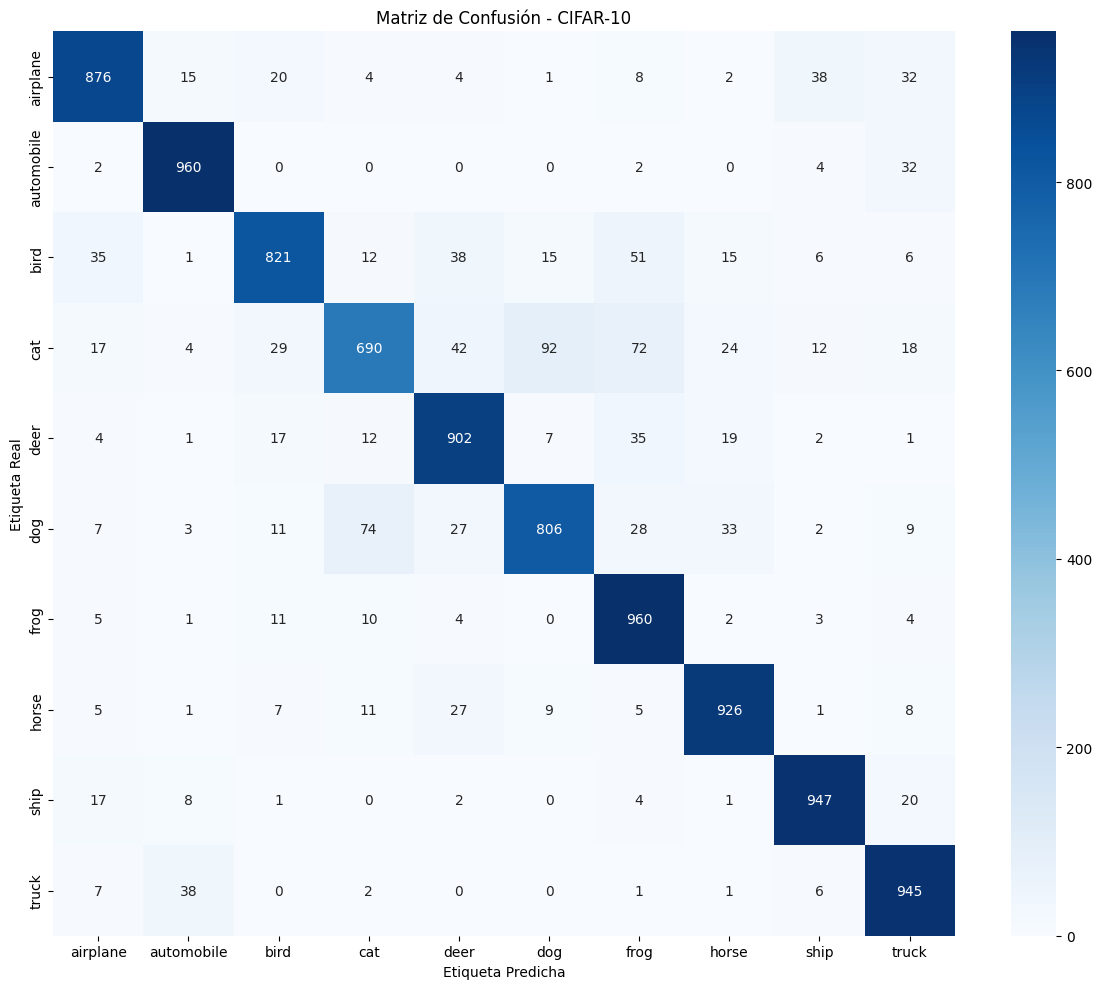


Reporte de Clasificación:
              precision    recall  f1-score   support

    airplane       0.90      0.88      0.89      1000
  automobile       0.93      0.96      0.94      1000
        bird       0.90      0.82      0.86      1000
         cat       0.85      0.69      0.76      1000
        deer       0.86      0.90      0.88      1000
         dog       0.87      0.81      0.84      1000
        frog       0.82      0.96      0.89      1000
       horse       0.91      0.93      0.92      1000
        ship       0.93      0.95      0.94      1000
       truck       0.88      0.94      0.91      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener todas las predicciones
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes)

# Visualizar matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión - CIFAR-10')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de Clasificación:")
print("="*70)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

## Paso 13: Análisis de errores - Ver ejemplos mal clasificados

Total de imágenes mal clasificadas: 1167 de 10000
Porcentaje de error: 11.67%


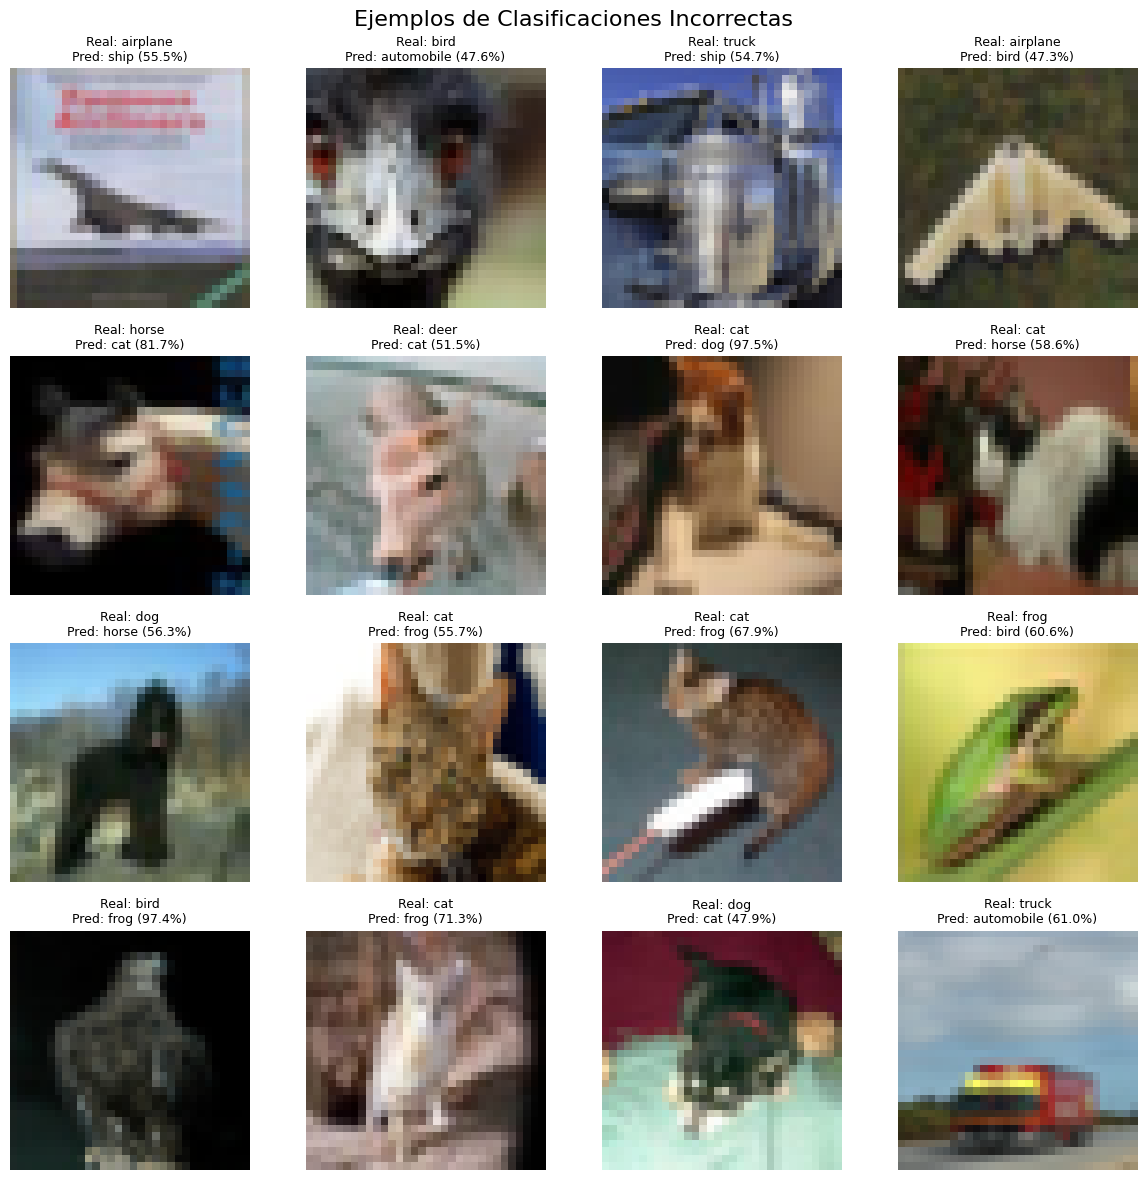

In [15]:
# Encontrar ejemplos mal clasificados
misclassified_indices = np.where(y_test != y_pred_classes)[0]

print(f"Total de imágenes mal clasificadas: {len(misclassified_indices)} de {len(y_test)}")
print(f"Porcentaje de error: {len(misclassified_indices)/len(y_test)*100:.2f}%")

# Visualizar algunos ejemplos mal clasificados
if len(misclassified_indices) > 0:
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Ejemplos de Clasificaciones Incorrectas', fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i < len(misclassified_indices):
            idx = misclassified_indices[i]
            ax.imshow(X_test[idx])

            true_class = class_names[y_test[idx]]
            pred_class = class_names[y_pred_classes[idx]]
            confidence = y_pred[idx][y_pred_classes[idx]] * 100

            ax.set_title(f'Real: {true_class}\nPred: {pred_class} ({confidence:.1f}%)',
                         fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

## Paso 14: Guardar el modelo

In [17]:
# Guardar el modelo completo (arquitectura y pesos) en el formato nativo recomendado
model.save('cifar10_classification_model.keras')
print("Modelo guardado como 'cifar10_classification_model.keras'")

# Guardar solo los pesos (requiere estrictamente la terminación .weights.h5)
model.save_weights('cifar10_classification.weights.h5')
print("Pesos del modelo guardados como 'cifar10_classification.weights.h5'")

Modelo guardado como 'cifar10_classification_model.keras'
Pesos del modelo guardados como 'cifar10_classification.weights.h5'


## Conclusiones

En esta práctica implementamos una red neuronal convolucional (CNN) utilizando Keras y TensorFlow para la clasificación de imágenes. La red neuronal se implementó para clasificar imágenes de objetos del mundo real en 10 categorías utilizando la base de datos CIFAR-10.

### Aspectos importantes de la implementación:

1. **Dataset CIFAR-10**: A diferencia de MNIST que tiene imágenes en escala de grises de dígitos escritos a mano, CIFAR-10 contiene imágenes a color (RGB) de objetos del mundo real, lo que representa un desafío más realista y complejo.

2. **Arquitectura del modelo**: Se utilizó una arquitectura CNN profunda con:
   - Tres bloques convolucionales con filtros de 32, 64 y 128
   - BatchNormalization después de cada capa convolucional para estabilizar el entrenamiento
   - MaxPooling para reducir la dimensionalidad espacial
   - Dropout (0.25 y 0.5) para prevenir el sobreajuste
   - Padding='same' para mantener las dimensiones espaciales

3. **Preprocesamiento**: Las imágenes RGB de 32x32 píxeles fueron normalizadas al rango [0, 1] y las etiquetas fueron convertidas a formato one-hot encoding.

4. **Data Augmentation**: Se aplicaron técnicas de aumento de datos (rotación, desplazamiento, volteo horizontal, zoom) para mejorar la capacidad de generalización del modelo y reducir el sobreajuste.

5. **Callbacks**: Se utilizaron:
   - EarlyStopping para detener el entrenamiento cuando no hay mejora en la pérdida de validación
   - ReduceLROnPlateau para ajustar dinámicamente la tasa de aprendizaje

6. **Evaluación completa**: El modelo fue evaluado mediante:
   - Métricas de precisión y pérdida
   - Matriz de confusión para visualizar las confusiones entre clases
   - Reporte de clasificación con precision, recall y f1-score por clase
   - Análisis de errores para identificar patrones en las clasificaciones incorrectas

### Resultados esperados:

El modelo de clasificación de CIFAR-10 típicamente alcanza una precisión entre 70-85% dependiendo de la arquitectura y el tiempo de entrenamiento. Algunas observaciones comunes:
- Las clases con objetos distintivos (airplane, ship) suelen tener mejor rendimiento
- Los animales similares (cat, dog) pueden confundirse entre sí
- Los vehículos (automobile, truck) también pueden ser difíciles de distinguir

### Diferencias con MNIST:

1. **Complejidad**: CIFAR-10 es significativamente más desafiante que MNIST debido a:
   - Imágenes a color (3 canales vs 1 canal)
   - Mayor variabilidad intra-clase
   - Objetos más complejos del mundo real

2. **Arquitectura**: Se requiere una red más profunda y con más parámetros para capturar las características de las imágenes RGB.

3. **Técnicas de regularización**: Es crucial usar data augmentation y dropout más agresivo debido a la mayor complejidad del problema.

### Aplicaciones prácticas:

Este tipo de modelo tiene aplicaciones en:
- Sistemas de visión por computadora para clasificación de objetos
- Vehículos autónomos para detección de objetos
- Sistemas de seguridad y vigilancia
- Organización automática de imágenes
- Asistentes virtuales con capacidades visuales
- Control de calidad en manufactura

### Posibles mejoras:

- Utilizar arquitecturas más modernas como ResNet, VGG, o EfficientNet
- Aplicar transfer learning usando modelos pre-entrenados en ImageNet
- Experimentar con diferentes optimizadores (SGD con momentum, RMSprop)
- Ajustar hiperparámetros como learning rate, batch size, y número de épocas
- Usar técnicas de ensemble combinando múltiples modelos

## Referencias

### CIFAR-10 Dataset:
Krizhevsky, A., & Hinton, G. (2009). Learning Multiple Layers of Features from Tiny Images. Technical Report, University of Toronto.

### Deep Learning y CNNs:
Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

### Keras y TensorFlow:
Chollet, F. (2018). Deep Learning with Python. Manning Publications.

### Arquitecturas de CNNs:
Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition. arXiv:1409.1556.

### Técnicas de Regularización:
Srivastava, N., et al. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting. Journal of Machine Learning Research, 15, 1929-1958.

### Batch Normalization:
Ioffe, S., & Szegedy, C. (2015). Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift. International Conference on Machine Learning.

### Data Augmentation:
Shorten, C., & Khoshgoftaar, T. M. (2019). A survey on Image Data Augmentation for Deep Learning. Journal of Big Data, 6(1), 60.

### Transfer Learning:
Yosinski, J., et al. (2014). How transferable are features in deep neural networks? Advances in Neural Information Processing Systems, 27.